# Reproduced Figure 6

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

#================================================================================ 
# ! IMPORTANT: UPDATE THIS PATH FOR YOUR OWN MACHINE!  
# 
# ➤ Please replace it with the full path to your "WD-IMBH-Relativistic-Tides" folder.
#   Example:
#        sys.path.append("/Users/your_username/your_project_folder/WD-IMBH-Relativistic-Tides")
#
#  Tip: Keep this notebook in the same directory as the "WD-IMBH-Relativistic-Tides" folder for easier path management.
import os 
os.chdir("/your_username/your_project_folder/WD-IMBH-Relativistic-Tides") 
# os.chdir("/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides")
print(os.getcwd())
#================================================================================ 


/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides


In [11]:
from matplotlib.lines import Line2D 
from scipy.interpolate import UnivariateSpline 

# ==========================================================
#  Expected .npz File Formats (for full reproducibility)
# ========================================================== 

"""
This script requires three pre-saved NumPy archive (.npz) files:

1. **'FIG_6_trajectory_data.npz'**
   - Contains: `trajectories` (object array of dicts)
   - Each dict has:
        'e_both': 1D array, eccentricity from full evolution (DT + GW)
        'rp_both': 1D array, pericenter radius from full evolution
        'e_gw':    1D array, eccentricity from GW-only evolution
        'rp_gw':   1D array, pericenter radius from GW-only evolution
        'label':   str, optional label (not used in plotting)

2. **'FIG_6_boundary_curves.npz'**
   - Contains:
        'e_grid':           1D array, common eccentricity grid (e.g., 0.1 to 0.999)
        'rp_plunge_p09':    1D array, plunge boundary for black hole spin +0.9
        'rp_plunge_m09':    1 D array, plunge boundary for spin -0.9
        'rp_tde_p09':       1D array, tidal disruption event (TDE) boundary for +0.9
        'rp_tde_m09':       1D array, TDE boundary for -0.9

3. **'FIG_6_annotation_points.npz'**
   - Contains:
        'yellow_points': 2D array of shape (N, 2), [[e, rp], ...] — peaks from full trajectories
        'blue_points':   2D array of shape (M, 2), [[e, rp], ...] — peaks from GW-only trajectories
   - Note: These are currently loaded but not used in this version; kept for future annotation.
"""

# ========================================================= 
#  Helper Functions
# =========================================================

def downsample_list(lst, steps):
    """
    Downsample a list by dividing it into 4 segments and applying different strides to each.
    """
    segment_length = len(lst) // 4
    result = []
    for i, step in enumerate(steps):
        start = i * segment_length
        end = (i + 1) * segment_length if i < 3 else None
        seg = lst[start:end]
        result.extend(seg[::max(1, step)])
    return result

def add_arrow_to_line(x, y, ax, position=0.5, size=15, color='k', arrowstyle='fancy'):
    """
    Add a directional arrow along a trajectory (x, y) at a specified relative position.
    """
    if len(x) < 3:
        return
    idx = int(len(x) * position)
    if idx <= 0 or idx >= len(x) - 1:
        return
    dx = x[idx + 1] - x[idx]
    dy = y[idx + 1] - y[idx]
    from matplotlib.patches import FancyArrowPatch
    arrow = FancyArrowPatch(
        (x[idx], y[idx]),
        (x[idx] + dx * 0.01, y[idx] + dy * 0.01),
        arrowstyle=arrowstyle,
        mutation_scale=size,
        color=color,
        zorder=14
    )
    ax.add_patch(arrow)

def smooth_connect(points, color, linestyle='--', linewidth=3, alpha=0.3, zorder=19):
    """
    Create a smooth interpolated curve through a list of points using cubic splines.
    If interpolation fails, fall back to a straight-line connection.
    """
    if len(points) < 2:
        return None
    pts = np.array(points)
    n = len(pts)
    t = np.linspace(0, 1, n)
    try:
        from scipy.interpolate import make_interp_spline
        spl_x = make_interp_spline(t, pts[:, 0], k=3, bc_type='natural')
        spl_y = make_interp_spline(t, pts[:, 1], k=3, bc_type='natural')
        t_smooth = np.linspace(0, 1, 300)
        x_smooth = spl_x(t_smooth)
        y_smooth = spl_y(t_smooth)
        line = plt.plot(x_smooth, y_smooth, color=color, linestyle=linestyle,
                        linewidth=linewidth, alpha=alpha, zorder=zorder)[0]
        return (x_smooth, y_smooth), line
    except Exception:
        plt.plot(pts[:, 0], pts[:, 1], color=color, linestyle=linestyle,
                 linewidth=linewidth, alpha=alpha, zorder=zorder)
        return None

In [12]:
# ==================================================================
#  Load All Data
# ===================================================================

# Load trajectory data (both full physics and GW-only)
traj_file = np.load('data_npz/FIG_6_trajectory_data.npz', allow_pickle=True)
trajectories = traj_file['trajectories']

# Load boundary curves: plunge and tidal disruption limits for spin ±0.9
boundaries = np.load('data_npz/FIG_6_boundary_curves.npz')
e_grid = boundaries['e_grid']
rp_plunge_p09 = boundaries['rp_plunge_p09']   # spin = +0.9
rp_plunge_m09 = boundaries['rp_plunge_m09']   # spin = -0.9
rp_tde_p09 = boundaries['rp_tde_p09']
rp_tde_m09 = boundaries['rp_tde_m09']

# Load annotated peak points
points = np.load('data_npz/FIG_6_annotation_points.npz')
yellow_points = points['yellow_points'].tolist()  # peaks from full evolution
blue_points = points['blue_points'].tolist()     # peaks from GW-only



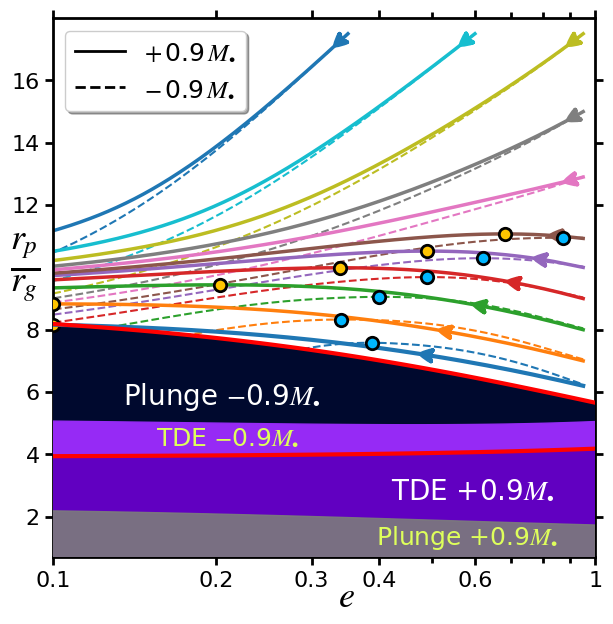

In [13]:
# ==============================================================
#  Plotting
# ==============================================================

plt.rcParams["mathtext.fontset"] = "stix"  # Use LaTeX-style math fonts
fig, ax = plt.subplots(figsize=(7, 7))

num_len = 50  # Approximate number of points to retain per trajectory

for i, traj in enumerate(trajectories):
    x_both = traj['e_both']
    y_both = traj['rp_both']
    x_gw = traj['e_gw']
    y_gw = traj['rp_gw']
    label = traj['label']

    # Compute adaptive downsampling steps for both trajectories
    step_both = [max(1, int(len(x_both)/4) // int(num_len)), 
                max(1, int(len(x_both)/4) // int(num_len*2)), 
                max(1, int(len(x_both)/4) // int(num_len*3)), 
                max(1, int(len(x_both)/4) // int(num_len*20))]
    step_gw = [max(1, int(len(x_gw)/4) // int(num_len)), 
                max(1, int(len(x_gw)/4) // int(num_len*2)), 
                max(1, int(len(x_gw)/4) // int(num_len*3)), 
                max(1, int(len(x_gw)/4) // int(num_len*20))]

    x_b_ds = downsample_list(x_both, step_both)
    y_b_ds = downsample_list(y_both, step_both)
    x_g_ds = downsample_list(x_gw, step_gw)
    y_g_ds = downsample_list(y_gw, step_gw)

    # Ensure monotonicity for spline fitting (sort by x if needed)
    x_g_ds, y_g_ds = np.array(x_g_ds), np.array(y_g_ds)
    if not np.all(np.diff(x_g_ds) > 0):
        sort_idx = np.argsort(x_g_ds)
        x_g_ds, y_g_ds = x_g_ds[sort_idx], y_g_ds[sort_idx]
    
    # Fit and extrapolate GW-only trajectory
    spline = UnivariateSpline(x_g_ds, y_g_ds, s=0.02)
    x_min, x_max = x_g_ds.min(), x_g_ds.max()
    x_new = np.linspace(x_min - (x_max - x_min) * 2.0, x_max, 200)
    y_new = spline(x_new)

    # Plot full (solid) and GW-only (dashed) trajectories
    if i == 0:
        ax.plot(x_b_ds, y_b_ds, '-', color=f'C{i}', linewidth=3, zorder=25)
    elif i == 1:
        ax.plot(x_b_ds, y_b_ds, '-', color=f'C{i}', linewidth=2.5, zorder=12)
    else:
        ax.plot(x_b_ds, y_b_ds, '-', color=f'C{i}', linewidth=2.5)
    ax.plot(x_new, y_new, '--', color=f'C{i}', linewidth=1.5, zorder=-12)

    # Add directional arrows on full trajectories
    mid_idx = min(20, len(x_b_ds) - 2)
    if len(x_b_ds) > 2 and i < len(x_b_ds) - 1:
        ax.annotate('', xy=(x_b_ds[mid_idx+1], y_b_ds[mid_idx+1]),
                    xytext=(x_b_ds[mid_idx], y_b_ds[mid_idx]),
                    arrowprops=dict(arrowstyle='fancy', color=f'C{i}', lw=3, mutation_scale=20),
                    zorder=15)

    # Mark peak (maximum rp) point for full trajectory (yellow)
    if len(y_b_ds) > 0:
        idx_max = np.argmax(y_b_ds)
        x_max1, y_max1 = x_b_ds[idx_max], y_b_ds[idx_max]
        if not (np.isclose(x_max1, 0.95) or np.isclose(y_max1, 17.5)):
            ax.scatter(x_max1, y_max1, color="#FFC400", s=80, edgecolors='black', linewidth=2, zorder=20)

    # Mark peak point for GW-only trajectory (blue)
    if len(y_new) > 0:
        idx_max = np.argmax(y_new)
        x_max1, y_max1 = x_new[idx_max], y_new[idx_max]
        if not (np.isclose(x_max1, 0.95) or np.isclose(y_max1, 17.5) or i in [9,10]):
            ax.scatter(x_max1, y_max1, color="#00B7FF", s=80, edgecolors='black', linewidth=2, zorder=30)
# ===================================================================
#  Draw Regions and Annotations
# ====================================================================

# Plunge and TDE regions for spin = +0.9 (light gray and purple)
ax.fill_between(e_grid, rp_plunge_p09, 0, color="#7C7C7CF8", alpha=0.9, zorder=12)
ax.fill_between(e_grid, rp_tde_p09 + 0.1, 0, color="#6100c1", alpha=1, zorder=11)
ax.plot(e_grid, rp_tde_p09 + 0.1, color='red', linewidth=3, zorder=26)

# Plunge and TDE regions for spin = -0.9 (dark blue and violet)
ax.fill_between(e_grid, rp_plunge_m09, 0, color="#00092EFE", alpha=1, zorder=10)
ax.plot(e_grid, rp_plunge_m09, color='red', linewidth=3, zorder=26)
ax.fill_between(e_grid, rp_tde_m09, 0, color="#962AF5", alpha=1, zorder=10)

# Region labels
ax.text(0.135, 5.6, r'Plunge $-$0.9$M_{\bullet}$', fontsize=20, color='white', zorder=13)
ax.text(0.155, 4.3, r'TDE $-$0.9$M_{\bullet}$', fontsize=18, color="#DEFF5B", zorder=17)
ax.text(0.42, 2.6, r'TDE +0.9$M_{\bullet}$', fontsize=20, color='white', zorder=14)
ax.text(0.395, 1.1, r'Plunge +0.9$M_{\bullet}$', fontsize=18, color="#DEFF5B", zorder=20)

# Legend (using black proxies for clarity)
legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, label=r'$\!\!\!\!+ $0.9$ \,M_{\bullet}$'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label=r'$\!\!\!\!- $0.9$\,M_{\bullet}$')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=18, frameon=True, fancybox=True, shadow=True)

# ==================================================================
#  Axes Configuration
# ==================================================================

# Set logarithmic scale for x-axis (eccentricity)
plt.xscale('log')

# Axis limits
ax.set_xlim(0.1, 1.0)
ax.set_ylim(0.7, 18)

# Custom tick positions and labels
ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.6, 1.0])
ax.set_xticklabels(['0.1', '0.2', '0.3', '0.4', '0.6', '1'])
ax.set_yticks([2, 4, 6, 8, 12, 14, 16])
ax.set_yticklabels(['2', '4', '6', '8', '12', '14', '16'])

# Axis labels
ax.text(0.335, -0.9, r'$e$', fontsize=26)
ax.text(0.0834, 9.65, r'$\frac{r_{{p} }}{r_{\mathrm{ }g }} $', fontsize=37, color='black', zorder=13)

# Italic 'g' subscript for rg (using DejaVu Sans italic)
from matplotlib import font_manager as fm
prop = fm.FontProperties(family='DejaVu Sans', style='italic')
# ax.text(0.087, 9.1, 'g', fontproperties=prop, fontsize=14)  # optional fine-tuning

# Tick and spine styling
ax.tick_params(axis='both', which='major', labelsize=16, direction='out', width=2, length=6, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='out', width=2, length=4, top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color("#000000")

plt.show()